## Começa como uma aplicação Spark

In [1]:
from pyspark.sql import SparkSession
import pyfractal as pf

if 'spark' in locals():
  spark.stop()
  del spark
spark = SparkSession.builder\
  .master("local[8]")\
  .config("spark.driver.memory", "2g")\
  .config("spark.jars.packages", "com.koloboke:koloboke-impl-jdk8:1.0.0,com.typesafe.akka:akka-remote_2.13:2.5.23")\
  .config("spark.jars", pf.fractal_jar_path())\
  .appName("FractalApp")\
  .getOrCreate()

:: loading settings :: url = jar:file:/home/viniciusvdias/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/viniciusvdias/.ivy2/cache
The jars for the packages stored in: /home/viniciusvdias/.ivy2/jars
com.koloboke#koloboke-impl-jdk8 added as a dependency
com.typesafe.akka#akka-remote_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-61ccd5e1-672e-4aef-b107-96f5d0cbc44a;1.0
	confs: [default]
	found com.koloboke#koloboke-impl-jdk8;1.0.0 in central
	found com.koloboke#koloboke-impl-common-jdk8;1.0.0 in central
	found com.koloboke#koloboke-api-jdk8;1.0.0 in central
	found com.typesafe.akka#akka-remote_2.13;2.5.23 in central
	found com.typesafe.akka#akka-actor_2.13;2.5.23 in central
	found com.typesafe#config;1.3.3 in central
	found org.scala-lang.modules#scala-java8-compat_2.13;0.9.0 in central
	found com.typesafe.akka#akka-stream_2.13;2.5.23 in central
	found com.typesafe.akka#akka-protobuf_2.13;2.5.23 in central
	found org.reactivestreams#reactive-streams;1.0.2 in central
	found com.typesafe#ssl-config-core_2.13;0.4.0 

## Construímos o contexto do Fractal, usado para iniciar aplicações de mineração

In [2]:
from pyfractal.model import FractalContext

sc = spark.sparkContext
if 'fc' in locals():
  fc.stop()
  del fc
fc = FractalContext(sc)

## Leitura de um grafo e construção de uma aplicação que obtém todos os subgrafos induzidos com 4 vértices

In [3]:
import os
fg = fc.unlabeledGraphFromAdjLists(f"{os.environ["FRACTAL_HOME"]}/data/karateclubsample") # leitura de um grafo no fractal

# RDD em Spark que representa o conjunto de subgrafos induzidos com 4 vértices
app = fg \
  .set("ws_external", "false")\
  .vfractoid()\
  .extend(4)\
  .subgraphs_networkx()


## Dispara a execução da aplicação, para obtenção dos subgrafos

In [4]:
# dispara a computação e coleta desses subgrafos
subgraphs = app \
  .collect()

## Visualiza alguns resultados

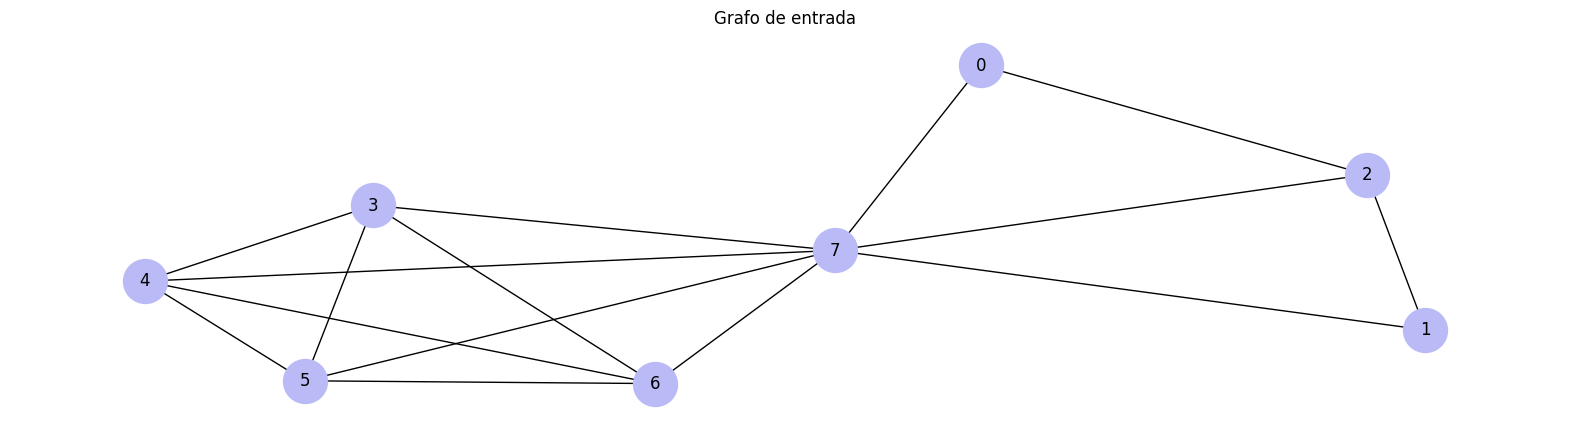

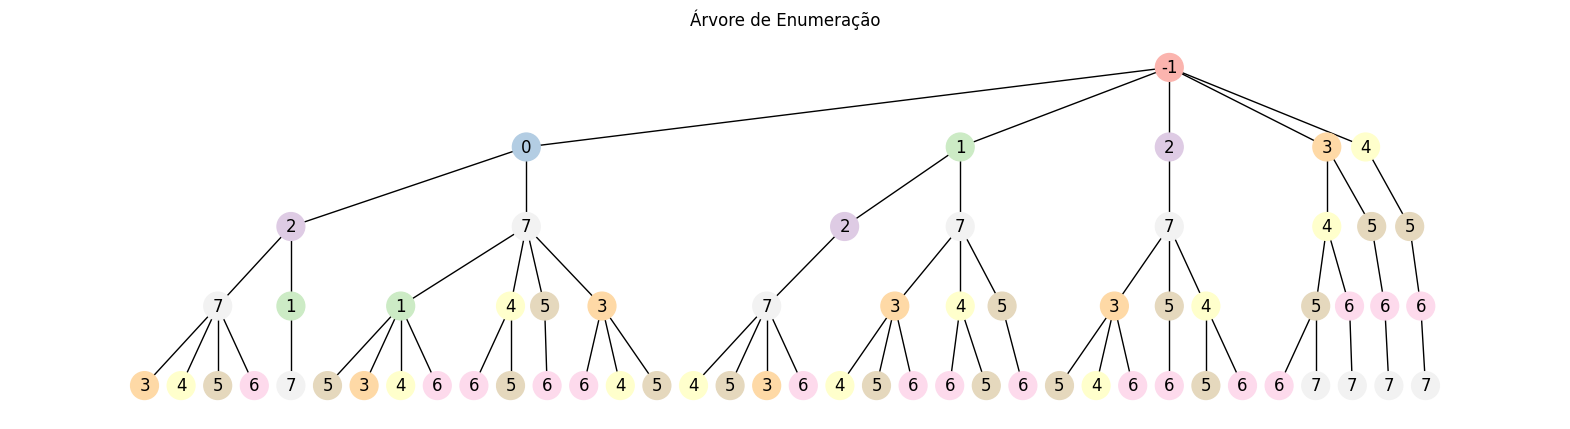

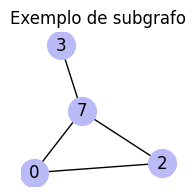

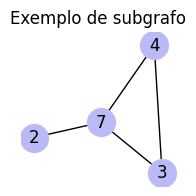

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
from itertools import count

wholegraph = fg\
  .set("ws_external", "false")\
  .vfractoid().extend(8).subgraphs_networkx().collect()[0]

allpaths = [list(s.nodes()) for s in subgraphs]
nodes = set()
for p in allpaths:
    for u in p:
        nodes.add(u)

num_nodes = len(nodes)
G = nx.Graph()
for root in range(num_nodes):
    G.add_node((-1,-1), vid=-1)
    paths = [p for p in allpaths if p[0] == root]
    paths_with_prefix = []
    for p in paths:
        prefix = []
        ppfirst = (p[0], tuple(prefix))
        pp = [ppfirst]
        G.add_edge((-1,-1), ppfirst)
        for i in range(1,len(p)):
            prefix.append(p[i-1])
            pp.append((p[i], tuple(prefix)))
            paths_with_prefix.append(pp)

    for p in paths_with_prefix:
        for u in p:
            G.add_node(u, vid=u[0])
        u = p[0]
        for i in range(1,len(p)):
            v = p[i]
            G.add_edge(u, v)
            u = v

figidx = 0

figidx += 1
plt.figure(figidx, figsize=(20,5)) 
plt.title("Grafo de entrada")
pos = graphviz_layout(wholegraph, prog="neato")
nx.draw(wholegraph, pos, with_labels = True, node_color="#babaf7", node_size=1000)

figidx += 1
plt.figure(figidx, figsize=(20,5))
plt.title("Árvore de Enumeração")
groups = set(nx.get_node_attributes(G,'vid').values())
mapping = dict(zip(sorted(groups),count()))
nodes = G.nodes()
colors = [mapping[G.nodes[n]['vid']] for n in nodes]
labels = nx.get_node_attributes(G, 'vid') 
pos = graphviz_layout(G, prog="dot")
nx.draw(G, pos, labels=labels, with_labels = True, node_color=colors, node_size=400, cmap=plt.cm.Pastel1)

figidx += 1
s = subgraphs[0]
plt.figure(figidx, figsize=(2,2))
plt.title("Exemplo de subgrafo")
pos = graphviz_layout(s, prog="neato")
nx.draw(s, pos, with_labels = True, node_color="#babaf7", node_size=400)

figidx += 1
s = subgraphs[11]
plt.figure(figidx, figsize=(2,2))
plt.title("Exemplo de subgrafo")
pos = graphviz_layout(s, prog="neato")
nx.draw(s, pos, with_labels = True, node_color="#babaf7", node_size=400)
    
plt.show()

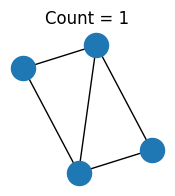

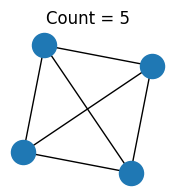

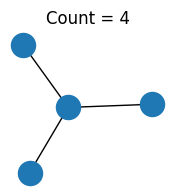

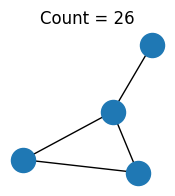

In [7]:
motifs = fg.motifs(4)
for m,c in motifs:
    plt.figure(figsize=(2,2))
    plt.title(f"Count = {c}")
    nx.draw(m)